<a href="https://colab.research.google.com/github/princealexanderm/-ICT_AI_ML/blob/main/ICT_AI_ML__Assignment_02_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment-2-- Regression

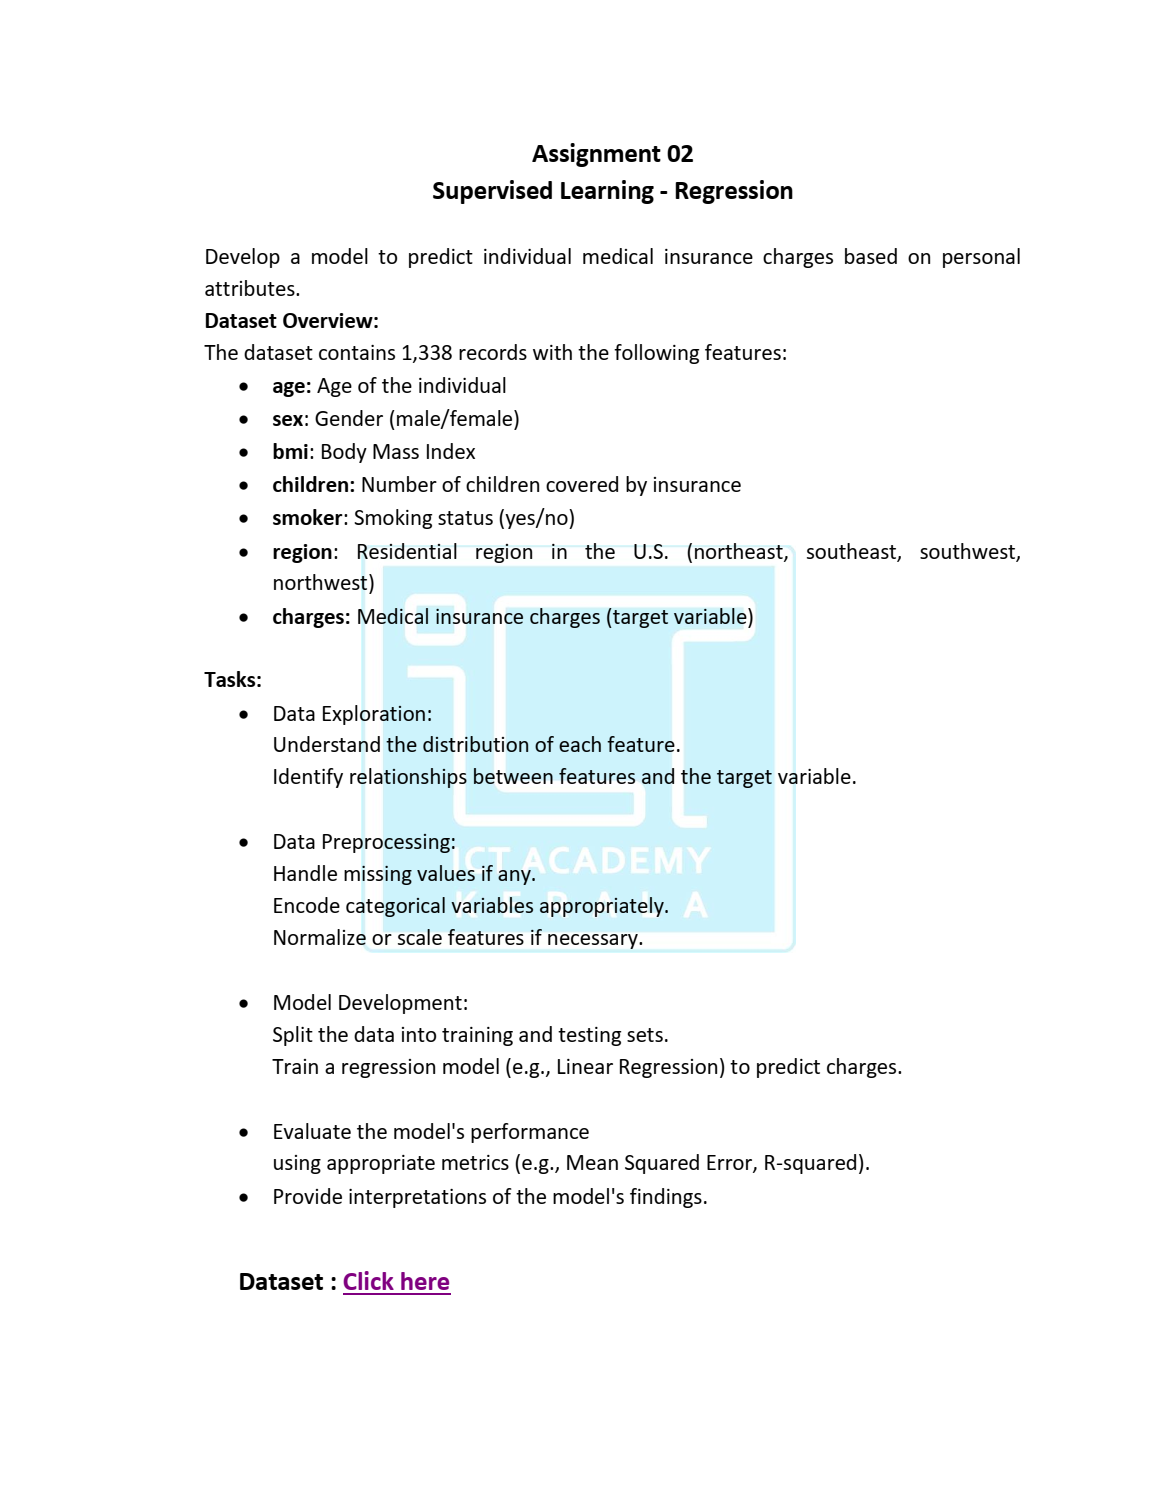

https://drive.google.com/file/d/1r48b6U8jFTjNmBNJ1lERh5AWSXljWFn2/view

#1. Loading data

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [ ]:
df=pd.read_csv('/content/insurance.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


#2. size and shape of the data

In [ ]:
df.size

9366

In [ ]:
df.shape

(1338, 7)

#3. Summary statistics of the data

In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


#4. Summary of the data

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


Numerical data
- age
- bmi
- children
- charges

Categorical data
- sex
- smoker
- religion

#5. Checking null values

In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


No null values

# 6. Checking outliers

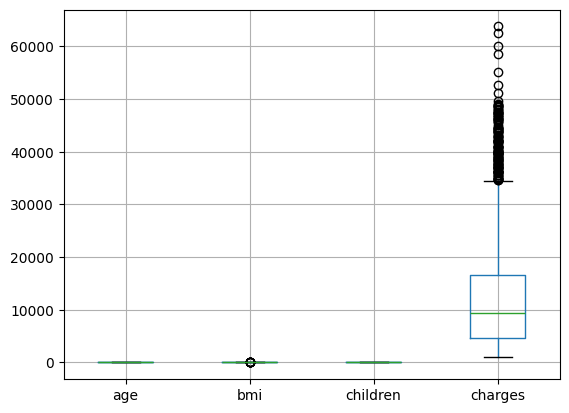

In [ ]:
df.boxplot()
plt.show()

- No outliers in independent variables
- charges is the target variable

#7. Histogram of numerical values

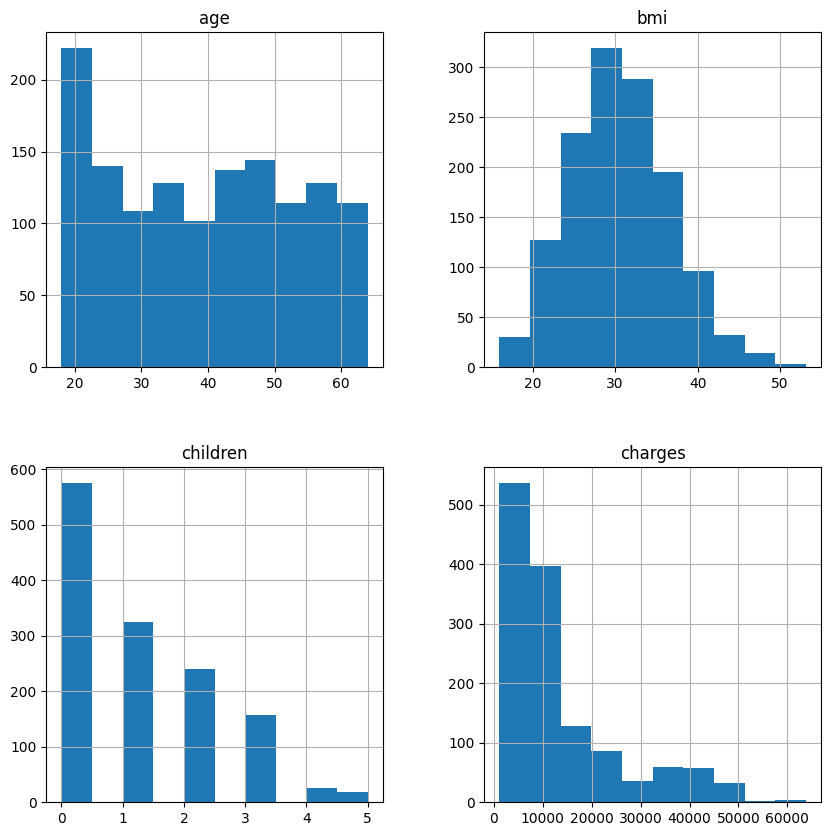

In [ ]:
df.hist(figsize=(10, 10))
plt.show()

In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

#8. Univariate analysis

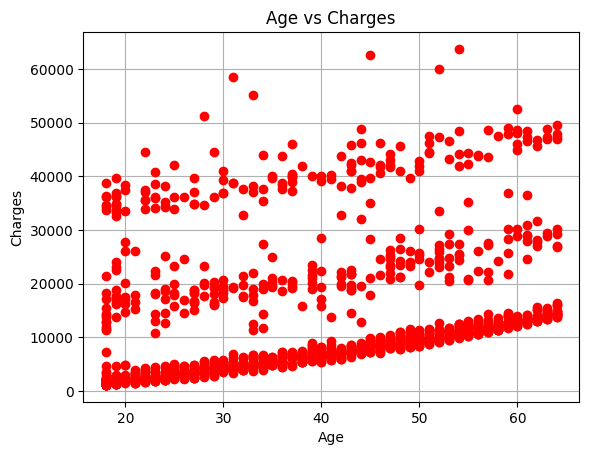

In [ ]:
plt.plot(df['age'],df['charges'],'ro')
plt.grid()
plt.xlabel('Age')
plt.ylabel('Charges')
plt.title('Age vs Charges')
plt.show()

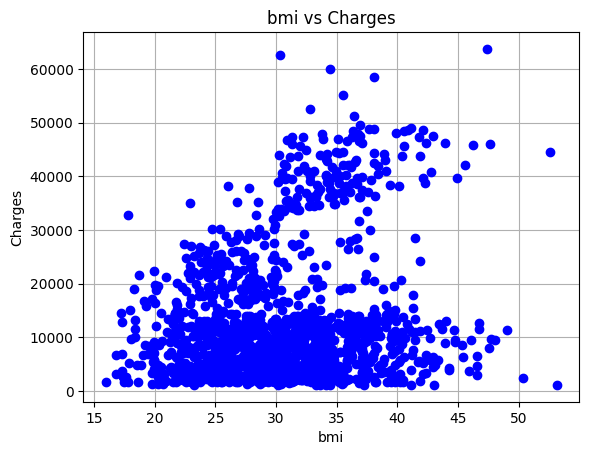

In [ ]:
plt.plot(df['bmi'],df['charges'],'bo')
plt.grid()
plt.xlabel('bmi')
plt.ylabel('Charges')
plt.title('bmi vs Charges')
plt.show()

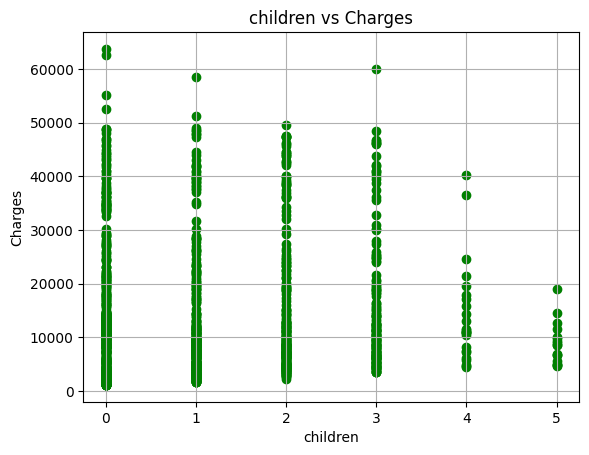

In [ ]:

plt.plot(df['children'],df['charges'],'go')
plt.grid()
plt.xlabel('children')
plt.ylabel('Charges')
plt.title('children vs Charges')
plt.show()

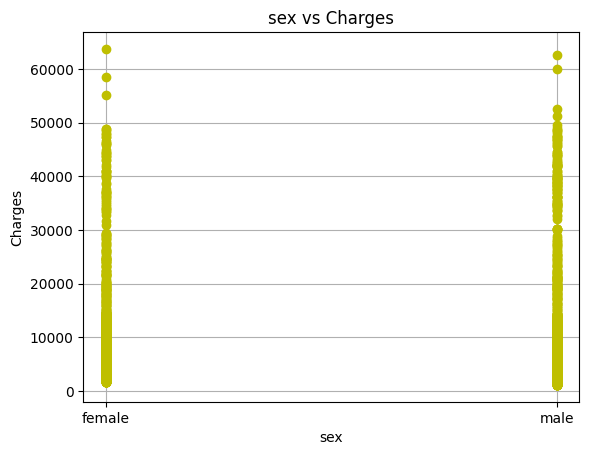

In [34]:
plt.plot(df['sex'],df['charges'],'yo')
plt.grid()
plt.xlabel('sex')
plt.ylabel('Charges')
plt.title('sex vs Charges')
plt.show()

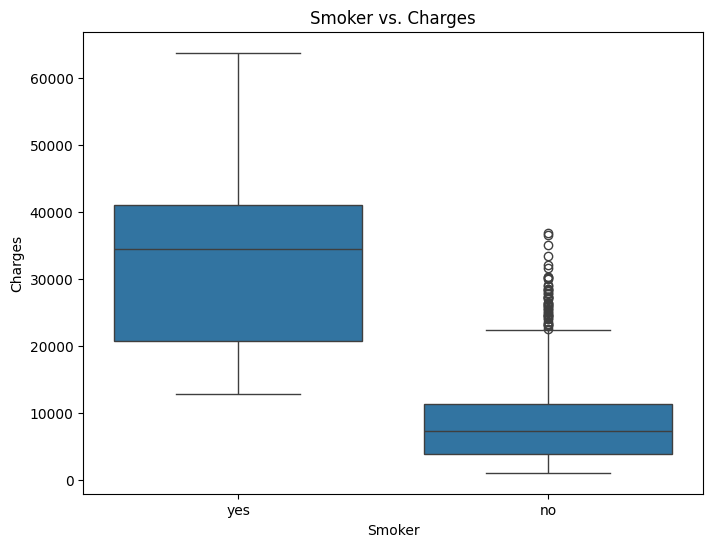

In [32]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Smoker vs. Charges')
plt.xlabel('Smoker')
plt.ylabel('Charges')
plt.show()

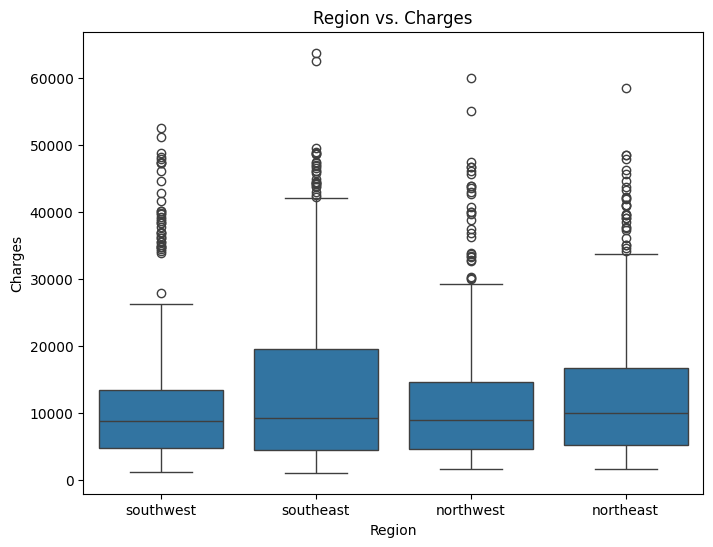

In [36]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='region', y='charges', data=df)
plt.title('Region vs. Charges')
plt.xlabel('Region')
plt.ylabel('Charges')
plt.show()

# 9.correlation

In [45]:
df1=df[['age','bmi','children','charges']]

In [46]:
df1.corr()

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


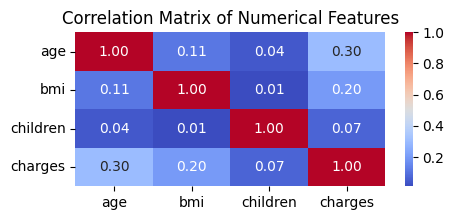

In [48]:
correlation_matrix = df1.corr()
plt.figure(figsize=(5, 2))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# 10. Encoding

In [49]:
df=pd.get_dummies(df,dtype='int')
df.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,1,0,0,1,0,0,0,1
1,18,33.770,1,1725.55230,0,1,1,0,0,0,1,0
2,28,33.000,3,4449.46200,0,1,1,0,0,0,1,0
3,33,22.705,0,21984.47061,0,1,1,0,0,1,0,0
4,32,28.880,0,3866.85520,0,1,1,0,0,1,0,0


# 11. Regression steps

## split the data into independent and target variables

In [50]:
x=df.drop('charges',axis=1)
y=df['charges']

## split the x data for training and testing

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [53]:
x_train.shape

(1070, 11)

In [54]:
x_test.shape

(268, 11)

#12. Scaling

In [55]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

#13. Creating model

In [56]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr=lr.fit(x_train,y_train)

In [57]:
y_pred=lr.predict(x_test)

In [60]:
y_pred[0:5]

array([ 8969.55027444,  7068.74744287, 36858.41091155,  9454.67850053,
       26973.17345656])

#14. Evaluating

In [63]:
from sklearn.metrics import r2_score,mean_squared_error
print(r2_score(y_test,y_pred))

0.7835929767120722


In [64]:
print(mean_squared_error(y_test,y_pred))

33596915.85136148
